# Si el mundo comiera sano, ¿qué le pasaría al campo?

**−53 %.** Ese es el recorte en la producción de carne de rumiantes —res, cordero, cabra— que calcula un ensamble de diez modelos económicos para 2050, nueve de los cuales reportan este sector, *si* el planeta adoptara una dieta saludable y sostenible. Ojo: no es un pronóstico de lo que va a pasar. Es lo que estos modelos proyectan **bajo ese escenario**, y depende de que existan políticas que lo empujen.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Food systems transformation would reshape global agriculture* — Gibson et al., Nature (2026)

**DOI:** [10.1038/s41586-026-10775-2](https://doi.org/10.1038/s41586-026-10775-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-15-transformacion-sistemas-alimentarios/notebook.ipynb)

🎬 **Video:** [Pendiente]

## De qué va esto

La comida que producimos empuja al planeta más allá de sus límites, y las malas dietas están entre los mayores factores de mortalidad del mundo. Frente a eso, hay un llamado a transformar los sistemas alimentarios. El equipo se hizo una pregunta poco explorada: **si esa transformación ocurriera, ¿cómo quedaría la agricultura mundial?**

Para responderlo, el equipo corrió un escenario llamado **EL2** —adoptar la dieta de referencia [EAT-Lancet](https://eatforum.org/eat-lancet-commission/) (más vegetales, mucha menos carne), mejorar la productividad agrícola y reducir a la mitad el desperdicio de comida— y lo proyectó a **2050** con un ensamble de **diez modelos económicos globales** ([AgMIP](https://agmip.org/)). La comparación es contra el **BAU** (*business-as-usual*): seguir como vamos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SECTOR_FOCO = 'RUM'          # sector a resaltar (RUM=carne rumiante, VFN=verduras/frutas...)
COLOR_BAJA  = '#DC2626'      # rojo: sectores que se contraen
COLOR_SUBE  = '#059669'      # emerald: sectores que crecen
COLOR_BAU   = '#BBBBBB'      # gris: trayectoria "seguir igual"
COLOR_EL2   = '#2563EB'      # azul CaM: escenario de transformación
FUENTE = ('Fuente: Gibson et al. (2026), Nature | '
          'Datos: ensamble AgMIP (Zenodo 17570720)')

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 3 CSV agregados a nivel modelo (el ensamble completo)
prod = pd.read_csv('datos/produccion_sector_modelo.csv')     # % cambio vs BAU 2050
tierra = pd.read_csv('datos/tierra_agricola_modelo.csv')      # % cambio vs 2020
tray = pd.read_csv('datos/trayectoria_produccion_agr.csv')    # trayectoria 2020-2050

# Nombres de sector con ortografía española correcta
prod['sector'] = prod['sector'].replace({
    'Lacteos': 'Lácteos',
    'Cultivos de azucar': 'Cultivos de azúcar',
})

# Mediana por sector (el estadístico que usa el paper para el ensamble)
med_sector = (prod.groupby(['item', 'sector'])['cambio_pct_vs_bau']
                  .median().sort_values())
n_por_sector = prod.groupby('item')['model'].nunique()

print('Sectores (mediana % producción vs BAU 2050, n modelos):')
for (item, sector), val in med_sector.items():
    print(f'  {sector:36s} {val:+6.1f}%   (n={n_por_sector[item]})')

agr = prod.loc[prod['item'] == 'AGR', 'cambio_pct_vs_bau']
print(f'\nProducción agrícola total: mediana {agr.median():+.1f}% vs BAU '
      f'(n={agr.size}), rango {agr.max():+.1f}% a {agr.min():+.1f}%')
print(f'Todos los modelos proyectan caída: '
      f'{(agr < 0).sum()}/{agr.size}')
print(f'Tierra agrícola: mediana {tierra["cambio_pct_vs_2020"].median():+.1f}% '
      f'vs 2020 (n={tierra.shape[0]}), '
      f'rango {tierra["cambio_pct_vs_2020"].max():+.1f}% a '
      f'{tierra["cambio_pct_vs_2020"].min():+.1f}%')

Sectores (mediana % producción vs BAU 2050, n modelos):
  Carne rumiante                        -52.8%   (n=9)
  Carne no-rumiante                     -44.6%   (n=9)
  Cultivos de azúcar                    -34.3%   (n=10)
  Cereales gruesos                      -29.2%   (n=10)
  Lácteos                               -27.2%   (n=9)
  Arroz                                 -23.2%   (n=10)
  Trigo                                 -22.9%   (n=10)
  Agricultura total                     -16.6%   (n=9)
  Oleaginosas                            +1.5%   (n=10)
  Verduras, frutas, nueces y legumbres  +23.4%   (n=9)

Producción agrícola total: mediana -16.6% vs BAU (n=9), rango -1.8% a -31.7%
Todos los modelos proyectan caída: 9/9
Tierra agrícola: mediana -5.0% vs 2020 (n=5), rango +1.0% a -26.2%


Aquí está el nuevo mapa del plato mundial.

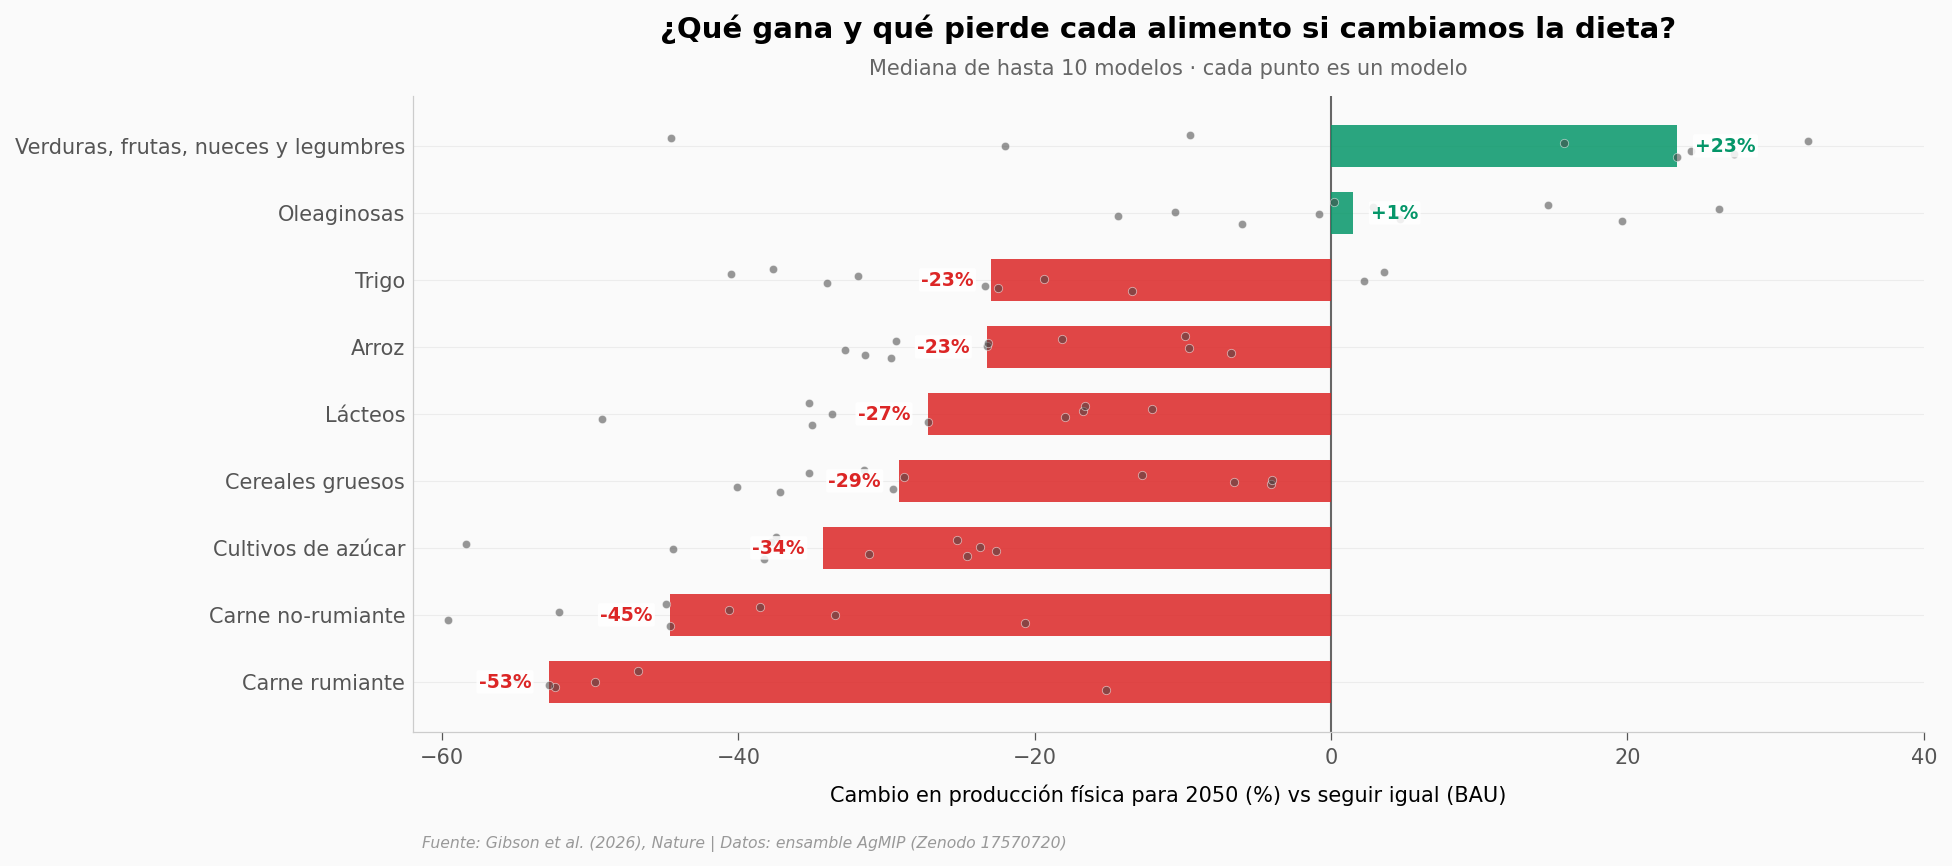

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)

# Solo los grupos de alimentos (excluimos AGR = agregado total, va aparte)
med_grupos = med_sector.drop('AGR', level='item')

etiquetas, medianas, colores = [], [], []
for (item, sector), val in med_grupos.items():
    etiquetas.append(sector)
    medianas.append(val)
    colores.append(COLOR_SUBE if val > 0 else COLOR_BAJA)

y = np.arange(len(etiquetas))
ax.barh(y, medianas, color=colores, alpha=0.85, height=0.62, zorder=3)

# Cada punto = un modelo del ensamble (curaduría visible)
for i, (item, sector) in enumerate(med_grupos.index):
    pts = prod.loc[prod['item'] == item, 'cambio_pct_vs_bau'].values
    jitter = np.linspace(-0.16, 0.16, len(pts))
    np.random.shuffle(jitter)
    ax.scatter(pts, np.full(len(pts), i) + jitter, color='#444444',
               s=16, alpha=0.55, zorder=5, edgecolors='white', linewidths=0.4)

ax.axvline(0, color='#666666', linewidth=1.0, zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(etiquetas, fontsize=10)
ax.set_xlabel('Cambio en producción física para 2050 (%) vs seguir igual (BAU)', fontsize=10)
ax.set_title('¿Qué gana y qué pierde cada alimento si cambiamos la dieta?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.035, 'Mediana de hasta 10 modelos · cada punto es un modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Etiquetas de valor al final de cada barra
for i, val in enumerate(medianas):
    ha = 'left' if val > 0 else 'right'
    off = 1.2 if val > 0 else -1.2
    ax.text(val + off, i, f'{val:+.0f}%', va='center', ha=ha,
            fontsize=9, fontweight='bold',
            color=(COLOR_SUBE if val > 0 else COLOR_BAJA),
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85),
            zorder=6)

ax.set_xlim(-62, 40)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/reestructuracion_sectores.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que salta a la vista: la transformación no reparte el golpe por igual. La **ganadería es la que más se contrae** —carne de rumiantes cerca de −53 %, carne de aves y cerdo −45 %, lácteos −27 %— mientras que **verduras, frutas, nueces y legumbres crecen +23 %**. El plato saludable de EAT-Lancet reordena literalmente qué produce el campo.

De nueve grandes grupos de alimentos, **solo dos suben**. Uno es el esperado (los vegetales que la dieta pide más). El otro es la sorpresa: **las oleaginosas quedan casi planas (+1,5 %)** cuando todo lo demás baja. Y la nube de puntos importa tanto como las barras: donde los modelos están apretados hay consenso; donde se abren, la magnitud sigue en discusión.

Menos producción de carne y más vegetales cambia otra cosa gigante: **cuánta tierra necesita el campo.** Aquí los modelos hablan más bajito —solo cinco reportan el dato— pero lo que dicen es notable.

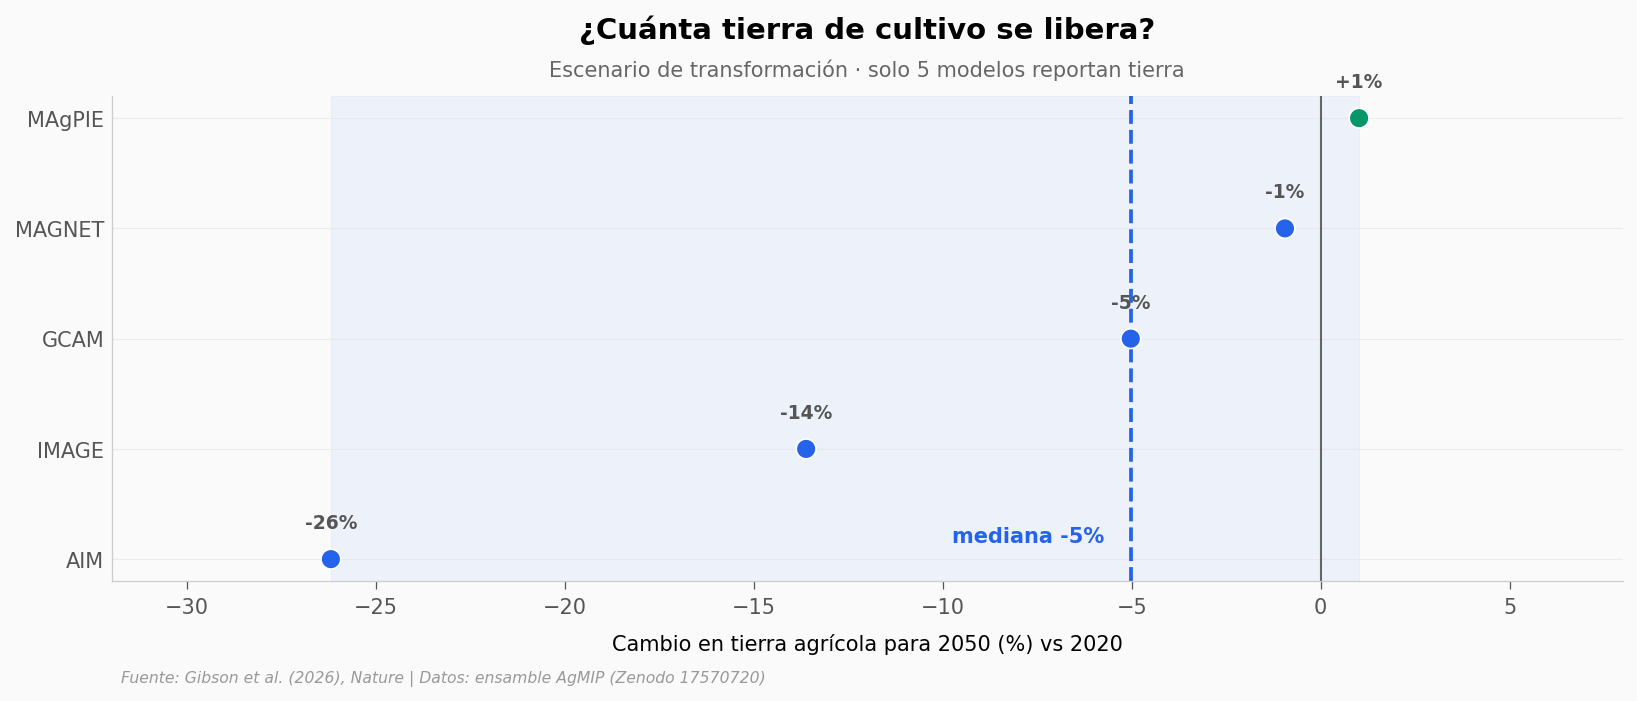

In [3]:
fig, ax = plt.subplots(figsize=(13, 4.2))

t = tierra.sort_values('cambio_pct_vs_2020').reset_index(drop=True)
y = np.arange(t.shape[0])
med = t['cambio_pct_vs_2020'].median()

# Banda del rango entre modelos
ax.axvspan(t['cambio_pct_vs_2020'].min(), t['cambio_pct_vs_2020'].max(),
           color=COLOR_EL2, alpha=0.06, zorder=1)
ax.axvline(med, color=COLOR_EL2, linewidth=1.8, linestyle='--', zorder=2)
ax.axvline(0, color='#666666', linewidth=1.0, zorder=2)

cols = [COLOR_SUBE if v > 0 else COLOR_EL2 for v in t['cambio_pct_vs_2020']]
ax.scatter(t['cambio_pct_vs_2020'], y, color=cols, s=90, zorder=5,
           edgecolors='white', linewidths=0.8)
for i, row in t.iterrows():
    ax.text(row['cambio_pct_vs_2020'], i + 0.28, f"{row['cambio_pct_vs_2020']:+.0f}%",
            ha='center', fontsize=9, fontweight='bold', color='#555555')

ax.text(med - 0.7, 0.12, f'mediana {med:+.0f}%', color=COLOR_EL2,
        fontsize=10, fontweight='bold', ha='right', va='bottom')
ax.set_yticks(y)
ax.set_yticklabels(t['model'], fontsize=10)
ax.set_xlabel('Cambio en tierra agrícola para 2050 (%) vs 2020', fontsize=10)
ax.set_title('¿Cuánta tierra de cultivo se libera?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, 'Escenario de transformación · solo 5 modelos reportan tierra',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-32, 8)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tierra_por_modelo.png', dpi=200, bbox_inches='tight')
plt.show()

Estos números son fotos de 2050. Pero, ¿**cuándo** empiezan a separarse los dos futuros? Sigamos la película año por año, desde hoy hasta mitad de siglo.

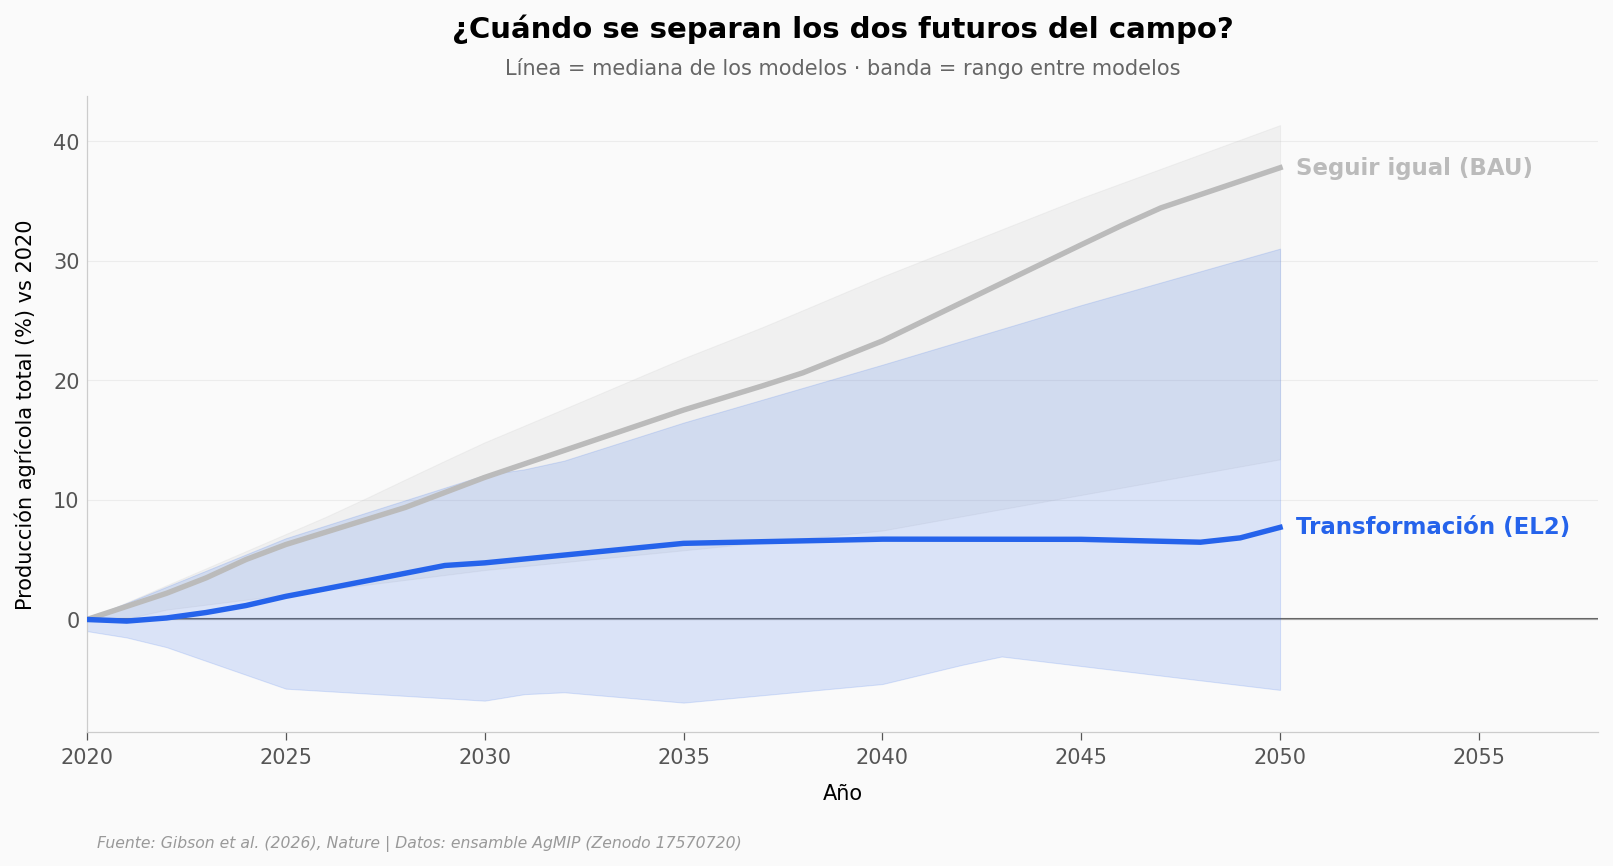

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

for scen, color, nombre in [('BAU', COLOR_BAU, 'Seguir igual (BAU)'),
                            ('EL2', COLOR_EL2, 'Transformación (EL2)')]:
    sub = tray[tray['scenario'] == scen]
    piv = sub.pivot_table(index='year', columns='model', values='cambio_pct_vs_2020')
    # Cada modelo reporta años distintos (algunos solo décadas). Interpolamos
    # cada uno a una malla anual común para que mediana/rango se calculen sobre
    # el MISMO conjunto de modelos en cada año (evita el "serrucho" espurio).
    full = np.arange(2020, 2051)
    piv = piv.reindex(full).interpolate(method='index', limit_area='inside')
    med = piv.median(axis=1)
    lo, hi = piv.min(axis=1), piv.max(axis=1)
    ax.fill_between(piv.index, lo, hi, color=color, alpha=0.15, zorder=2)
    ax.plot(piv.index, med, color=color, linewidth=2.6, zorder=4)
    # etiqueta inline al final
    ax.text(2050.4, med.iloc[-1], nombre, color=color, fontsize=11,
            fontweight='bold', va='center')

ax.axhline(0, color='#666666', linewidth=1.0, zorder=1)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Producción agrícola total (%) vs 2020', fontsize=10)
ax.set_title('¿Cuándo se separan los dos futuros del campo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.035, 'Línea = mediana de los modelos · banda = rango entre modelos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(2020, 2058)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/trayectoria_bau_el2.png', dpi=200, bbox_inches='tight')
plt.show()

Ambos futuros siguen creciendo —el mundo produce más comida en 2050 pase lo que pase— pero el de la transformación crece **mucho menos**. Queda una pregunta clave para no exagerar: ¿los diez modelos **coinciden** en esa caída, o es el promedio de opiniones muy distintas?

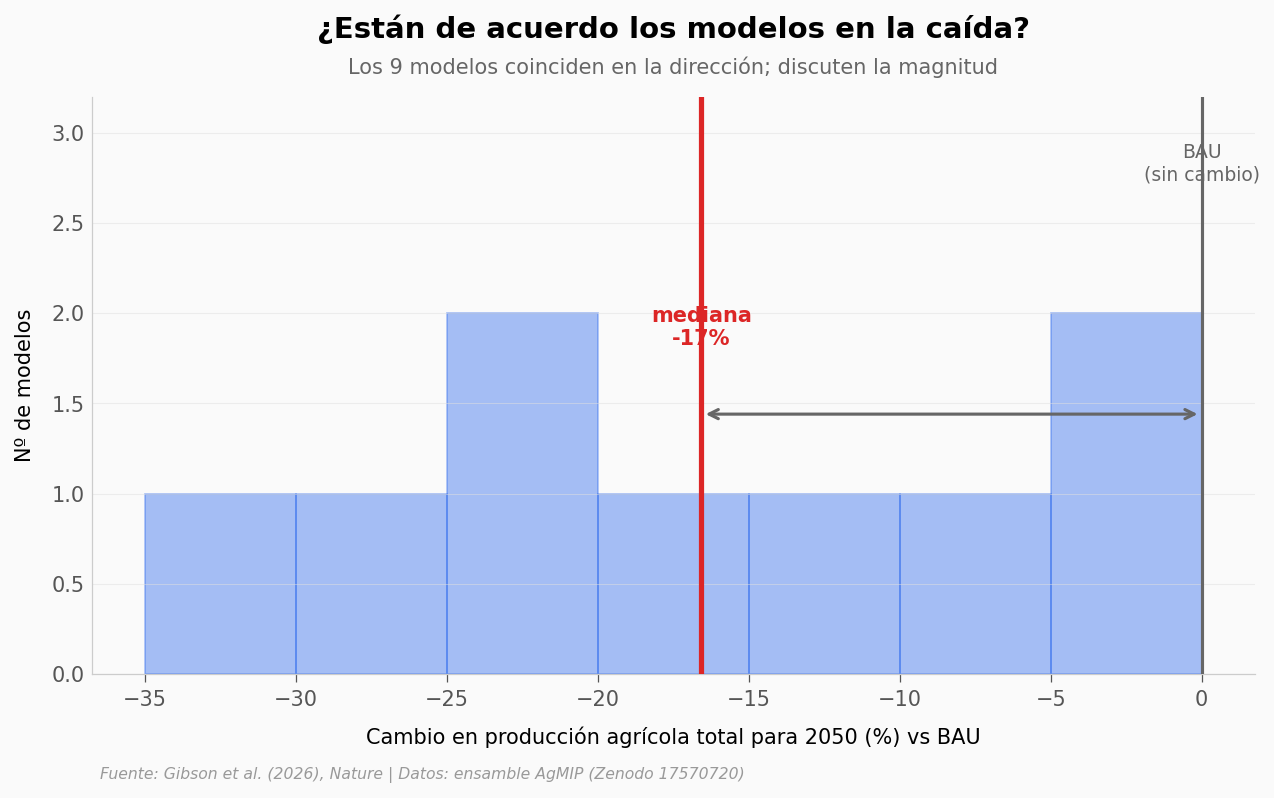

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = prod.loc[prod['item'] == 'AGR', 'cambio_pct_vs_bau'].values
med = np.median(vals)

n, bins, patches = ax.hist(vals, bins=np.arange(-35, 5, 5), color=COLOR_EL2,
                           alpha=0.4, edgecolor=COLOR_EL2, linewidth=0.8)
y_max = max(n.max() * 1.25, 3.2)
ax.set_ylim(0, y_max)

ax.axvline(0, color='#666666', linewidth=1.5, zorder=3)
ax.text(0, y_max * 0.92, 'BAU\n(sin cambio)', color='#666666', fontsize=9,
        ha='center', va='top')
ax.axvline(med, color=COLOR_BAJA, linewidth=2.5, zorder=4)
ax.text(med, y_max * 0.60, f'mediana\n{med:+.0f}%', color=COLOR_BAJA,
        fontsize=10, fontweight='bold', ha='center', va='center')

ax.annotate('', xy=(med, y_max * 0.45), xytext=(0, y_max * 0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

ax.set_xlabel('Cambio en producción agrícola total para 2050 (%) vs BAU', fontsize=10)
ax.set_ylabel('Nº de modelos', fontsize=10)
ax.set_title('¿Están de acuerdo los modelos en la caída?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, f'Los {len(vals)} modelos coinciden en la dirección; discuten la magnitud',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/consenso_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La producción agrícola total baja ~17 % vs BAU en 2050 | ✅ | Mediana reproducida −16,6 % (n=9); los 9 modelos coinciden en la dirección. Rango −2 % a −32 %. Coincide con el −17 % del paper. |
| La ganadería es lo que más se contrae (producción física) | ✅ | Rumiantes −53 %, no-rumiantes −45 %, lácteos −27 % (medianas, n=9). |
| Verduras, frutas, nueces y legumbres suben ~23 % | ✅ | Mediana física reproducida +23,4 % (n=9). El paper reporta +23 % en *valor*; aquí coincide en cantidad física. |
| La tierra agrícola baja ~6 % vs 2020 | ⚠️ | Mediana −5,0 % con los **5** modelos que reportan tierra (el paper cita −6 %). Rango +1 % a −26 % idéntico al paper. Muestra pequeña. |
| El valor de la producción caería US$1,6 billones (−26 %) bajo el escenario | ⚠️ | **Citado del paper, no reproducido.** Las unidades de valor difieren entre modelos, así que este notebook no lo recalcula (honestidad de fuente). |

> **Limitaciones:** (1) Son proyecciones de **modelos**, no observaciones — dependen de los supuestos de política del escenario; el propio estudio subraya que la transformación **no es inevitable**. (2) La tierra solo la reportan 5 de los 10 modelos. (3) Las cifras de **valor económico** ($1,6 billones, ganadería −49 a −83 %) se citan del paper: las unidades monetarias no son homogéneas entre modelos y no las reproducimos aquí. (4) Todo es a escala **mundial**; por región el cuadro puede cambiar.

### Ahora tú

1. **¿Qué modelo es el más "optimista" con la tierra?** Ordena `tierra` por `cambio_pct_vs_2020` y mira quién queda arriba. *(Pista: `tierra.sort_values('cambio_pct_vs_2020')`.)*
2. **¿Cambia la historia si usas el promedio en vez de la mediana?** Compara `.median()` con `.mean()` por sector. *(Pista: los modelos extremos jalan más la media.)*
3. **¿En qué año el escenario de transformación deja de crecer tan rápido?** Filtra `tray` por `scenario == 'EL2'` y busca dónde la pendiente se aplana. *(Pista: `tray[tray.scenario=='EL2'].groupby('year').median(numeric_only=True)`.)*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánta menos carne, cuánta más verdura? Comparemos ganadería vs vegetales.
ganaderia = ['RUM', 'NRM', 'DRY']            # rumiantes, no-rumiantes, lácteos
vegetales = ['VFN', 'OSD']                    # verduras/frutas/legumbres, oleaginosas

for grupo, items in [('Ganadería', ganaderia), ('Vegetales', vegetales)]:
    sub = prod[prod['item'].isin(items)]
    med = sub.groupby('item')['cambio_pct_vs_bau'].median()
    print(f'{grupo}:')
    for it, val in med.items():
        sector = prod.loc[prod['item'] == it, 'sector'].iloc[0]
        print(f'  {sector:36s} {val:+6.1f}%')
    print()

# Reto: cambia SECTOR_FOCO arriba (celda de configuración) y vuelve a correr
# el notebook para resaltar otro alimento en la gráfica principal.

Ganadería:
  Lácteos                               -27.2%
  Carne no-rumiante                     -44.6%
  Carne rumiante                        -52.8%

Vegetales:
  Oleaginosas                            +1.5%
  Verduras, frutas, nueces y legumbres  +23.4%



---

## Fuentes

**Paper**: [Food systems transformation would reshape global agriculture](https://doi.org/10.1038/s41586-026-10775-2)  
*Nature, 2026-07-15*

**Dataset canónico**: [Data for 'Food systems transformation would reshape global agriculture'](https://zenodo.org/records/17570720)  
*ensamble AgMIP a nivel de modelo (Zenodo)*

**Referencias citadas**: [Code for Figures 1-3 of Submitted Manuscript](https://zenodo.org/records/14876855)

*14 afirmaciones del notebook verificadas contra estas fuentes*